The dataset contains separate training and testing files.
For this task, only the training dataset is used since it includes the target variable required for model building.

In [100]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [114]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [102]:
from google.colab import files
uploaded = files.upload()

Saving loan_data.csv to loan_data (4).csv


In [103]:
import pandas as pd
df = pd.read_csv("loan_data.csv")
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [104]:
df.info

<bound method DataFrame.info of       Loan_ID  Gender Married Dependents     Education Self_Employed  \
0    LP001002    Male      No          0      Graduate            No   
1    LP001003    Male     Yes          1      Graduate            No   
2    LP001005    Male     Yes          0      Graduate           Yes   
3    LP001006    Male     Yes          0  Not Graduate            No   
4    LP001008    Male      No          0      Graduate            No   
..        ...     ...     ...        ...           ...           ...   
609  LP002978  Female      No          0      Graduate            No   
610  LP002979    Male     Yes         3+      Graduate            No   
611  LP002983    Male     Yes          1      Graduate            No   
612  LP002984    Male     Yes          2      Graduate            No   
613  LP002990  Female      No          0      Graduate           Yes   

     ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0               5849                0.0         NaN             360.0   
1               4583             1508.0       128.0             360.0   
2               3000                0.0        66.0             360.0   
3               2583             2358.0       120.0             360.0   
4               6000                0.0       141.0             360.0   
..               ...                ...         ...               ...   
609             2900                0.0        71.0             360.0   
610             4106                0.0        40.0             180.0   
611             8072              240.0       253.0             360.0   
612             7583                0.0       187.0             360.0   
613             4583                0.0       133.0             360.0   

     Credit_History Property_Area Loan_Status  
0               1.0         Urban           Y  
1               1.0         Rural           N  
2               1.0         Urban           Y  
3               1.0         Urban           Y  
4               1.0         Urban           Y  
..              ...           ...         ...  
609             1.0         Rural           Y  
610             1.0         Rural           Y  
611             1.0         Urban           Y  
612             1.0         Urban           Y  
613             0.0     Semiurban           N  

[614 rows x 13 columns]>

In [115]:
df.columns

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status',
       'Income_to_Loan'],
      dtype='object')

In [116]:
df.isnull().sum()

,0
Loan_ID,0
Gender,0
Married,0
Dependents,0
Education,0
Self_Employed,32
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,0
Loan_Amount_Term,14


In [117]:
df['Dependents'] = df['Dependents'].replace('3+', '3').astype(float)
num_cols = ['ApplicantIncome', 'LoanAmount', 'Credit_History', 'Dependents']
df[num_cols] = df[num_cols].fillna(df[num_cols].mean())
cat_cols = ['Gender', 'Married', 'Education']
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [118]:
df = df.dropna(subset=['Loan_Status'])

In [119]:
# Fill missing categorical values
gender_mode = df['Gender'].mode()
if not gender_mode.empty:
    df['Gender'] = df['Gender'].fillna(gender_mode[0])

In [120]:
### Categorical Values
df['Gender'] = df['Gender'].map({'Male':1, 'Female':0})
df['Loan_Status'] = df['Loan_Status'].map({'Y':1, 'N':0})

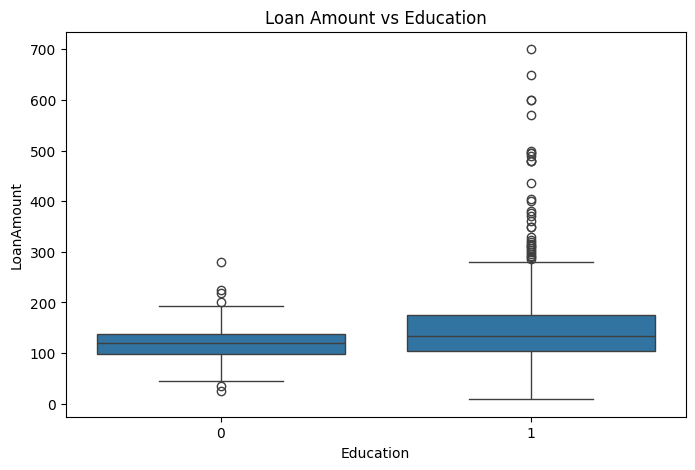

In [121]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Education', y='LoanAmount', data=df)
plt.title("Loan Amount vs Education")
plt.show()


In [127]:

df['Income_to_Loan'] = df['ApplicantIncome'] / df['LoanAmount']
df['Married'] = df['Married'].map({'Yes':1, 'No':0}).astype(float).fillna(0)
df['Education'] = df['Education'].map({'Graduate':1, 'Not Graduate':0}).astype(float).fillna(0)
# Fill any NaNs that might have been introduced by the map operations
df['Married'] = df['Married'].fillna(0)
df['Education'] = df['Education'].fillna(0)
X = df[['ApplicantIncome', 'LoanAmount', 'Credit_History', 'Gender', 'Married', 'Education', 'Dependents', 'Income_to_Loan']]
y = df['Loan_Status']

In [128]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [130]:
smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)

In [131]:
model = RandomForestClassifier(
    n_estimators=200,
    max_depth=7,
    min_samples_split=5,
    class_weight='balanced',
    random_state=42
)
model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=7,
                       min_samples_split=5, n_estimators=200, random_state=42)

In [132]:
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.8292682926829268
Confusion Matrix:
 [[22 16]
 [ 5 80]]
Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.58      0.68        38
           1       0.83      0.94      0.88        85

    accuracy                           0.83       123
   macro avg       0.82      0.76      0.78       123
weighted avg       0.83      0.83      0.82       123

